I'll use this notebook to pull in the retinal_labels_processed.csv file from data/processed and create an initial cnn.

*Note*: Retinal scan image files need to be stored in data/raw/retinal_scan_images. 

In [4]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('../data/processed/retinal_labels_processed.csv')


In [6]:
df["exists"] = df["filepath"].apply(os.path.exists)
print(df["exists"].value_counts())


exists
True    3662
Name: count, dtype: int64


In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['dr_binary'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['dr_binary'],
    random_state=42
)

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    horizontal_flip=True,
    validation_split=0.0
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="dr_binary",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw"
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="dr_binary",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=False
)

Found 2563 validated image filenames.
Found 549 validated image filenames.


In [9]:
print(df["dr_binary"].value_counts(normalize=True))

dr_binary
1    0.5071
0    0.4929
Name: proportion, dtype: float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    3662 non-null   object
 1   diagnosis  3662 non-null   int64 
 2   dr_binary  3662 non-null   int64 
 3   filepath   3662 non-null   object
 4   exists     3662 non-null   bool  
dtypes: bool(1), int64(2), object(2)
memory usage: 118.1+ KB


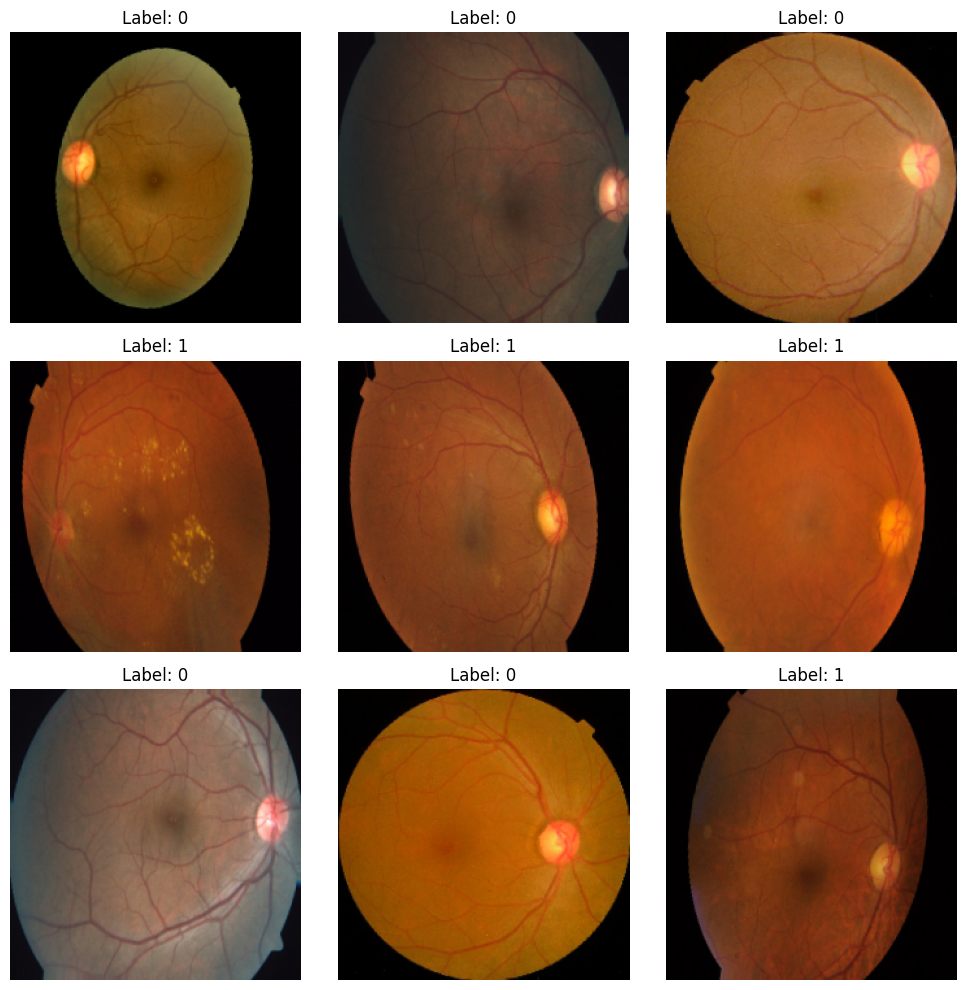

In [11]:
images, labels = next(train_generator)

def show_batch(images, labels, n=9):
    plt.figure(figsize=(10,10))
    
    for i in range(n):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(f"Label: {int(labels[i])}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_batch(images, labels)

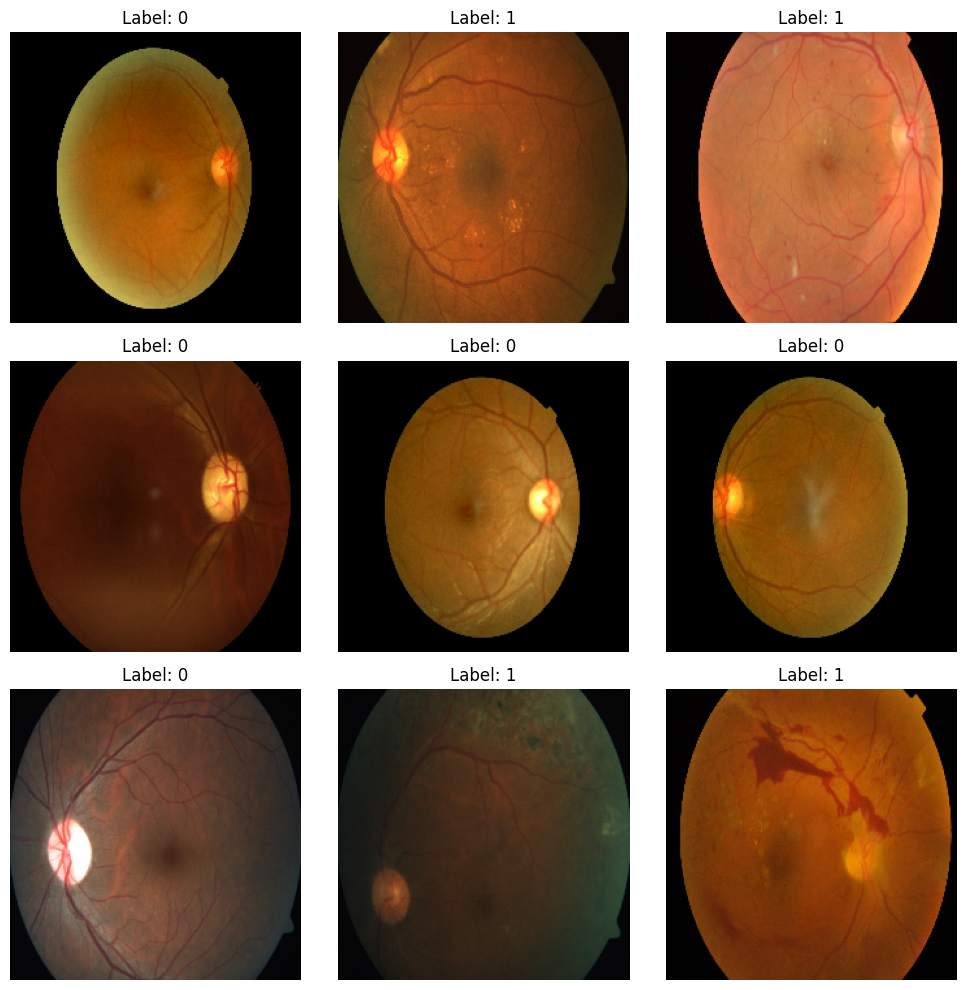

Batch label distribution: [15 17]


In [12]:
val_images, val_labels = next(val_generator)
show_batch(val_images, val_labels)

print("Batch label distribution:", np.bincount(labels.astype(int)))

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

In [14]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.8623 - loss: 0.3285 - val_accuracy: 0.9454 - val_loss: 0.1910
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.9278 - loss: 0.2209 - val_accuracy: 0.9162 - val_loss: 0.2308
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.9220 - loss: 0.2182 - val_accuracy: 0.9326 - val_loss: 0.1910
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.9356 - loss: 0.2026 - val_accuracy: 0.9454 - val_loss: 0.1803
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.9372 - loss: 0.1967 - val_accuracy: 0.9508 - val_loss: 0.1829
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.9391 - loss: 0.1857 - val_accuracy: 0.9472 - val_loss: 0.1712
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.9454 - loss: 0.1827 - val_accuracy: 0.9308 - val_loss: 0.2069
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 236s 3s/step - accuracy: 0.9426 - loss: 0.1732 - val_accuracy: 0.9563 - v

In [16]:
pred_probs = baseline_model.predict(val_generator)
pred_labels = (pred_probs > 0.5).astype(int).flatten()

true_labels = val_df["dr_binary"].values

18/18 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step


In [17]:
from sklearn.metrics import confusion_matrix, classification_report, recall_score

cm = confusion_matrix(true_labels, pred_labels)
print(cm)

print(classification_report(true_labels, pred_labels))

recall = recall_score(true_labels, pred_labels)
print("Positive-class recall:", recall)

[[260  11]
 [ 15 263]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       271
           1       0.96      0.95      0.95       278

    accuracy                           0.95       549
   macro avg       0.95      0.95      0.95       549
weighted avg       0.95      0.95      0.95       549

Positive-class recall: 0.9460431654676259


In [18]:
model_dir = '../models/model3_cnn/saved_model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

baseline_model.save(os.path.join(model_dir, 'baseline_cnn_model.keras'))